In [1]:
import sys
import os

path = os.path.join('SPOC', 'spoc')
sys.path.append(path)

path = os.path.join('SPOC')
sys.path.append(path)

In [2]:
import spoc_base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D
import matplotlib as mpl
import seaborn as sns
sns.set(font_scale=1.4)
from tqdm.notebook import tqdm
from scipy.sparse.linalg import eigs
import numba
numba.config.THREADING_LAYER = 'threadsafe'
import random
import numbers
# # import dask.array as da
# from dask.array import stats as dask_stats
# import gc

import scipy.stats as sps

from sklearn.cluster import KMeans

from spoc import generate_spoc_model as gen_model
from spoc_base import SPOC
from generate_spoc_model import find_theta_error, find_b_error

from IPython.display import clear_output

In [3]:
import numpy as np
import scipy.sparse.linalg as spla
from scipy.optimize import linprog
from scipy.linalg import norm
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from itertools import permutations, combinations
import cvxpy


def mixedSCORE(A, K, verbose=False):
    # SCORE step
    if verbose:
        print('Get ratios --------')

    score_out = SCORE(A, K)
    R = score_out['R']

    if verbose:
        print('Vertex hunting --------')

    vh_out = vertexHunting(R, K, verbose)

    if verbose:
        print('Get the membership ----')

    memb_out = getMembership(R, vh_out['vertices'], K, score_out['eig_values'], score_out['eig_vectors'])
    memberships = memb_out['memberships']
    degrees = memb_out['degrees']

    if verbose:
        print('Get the purity scores and hard clustering results ----')

    purity = memberships.max(axis=1)
    major_labels = memberships.argmax(axis=1)

    return {
        'R': R,
        'L': vh_out['L'],
        'vertices': vh_out['vertices'],
        'centers': vh_out['centers'],
        'memberships': memberships,
        'degrees': degrees,
        'purity': purity,
        'major_labels': major_labels,
        'community_matrix': memb_out['community_matrix']
    }


def SCORE(A, K, threshold=None):
    if not isinstance(A, np.ndarray):
        A = np.array(A)
    if (A < 0).any():
        raise ValueError('Entries of adjacency matrix A should be non-negative!')

    if not np.allclose(A, A.T):
        raise ValueError('Adjacency matrix A is not symmetric!')

    eig_vals, eig_vecs = spla.eigs(A, k=K)
    eig_vecs = eig_vecs.real
    R = eig_vecs[:, 1:K] / eig_vecs[:, 0].reshape(-1, 1)

    if threshold is None:
        threshold = np.inf

    R[R > threshold] = threshold
    R[R < -threshold] = -threshold

    return {
        'R': R,
        'eig_values': eig_vals.real[:K],
        'eig_vectors': eig_vecs
    }


def vertexHunting(R, K, verbose=False):
    L_candidate = np.arange(K+1, 3*K+1)
    out_list = []

    for L in L_candidate:
        if verbose:
            print(f'L = {L}')

        kmeans = KMeans(n_clusters=L, max_iter=100, n_init=100).fit(R)
        centers = kmeans.cluster_centers_

        out = vertexSearch(centers, K)
        if verbose:
            print(f'dist = {out["dist"]}')

        out_list.append(out)

    delta_L = []
    for i in range(len(L_candidate)):
        if i == 0:
            V_Lminus1 = KMeans(n_clusters=K, max_iter=100, n_init=100).fit(R).cluster_centers_
        else:
            V_Lminus1 = out_list[i - 1]['vertices']

        V_L = out_list[i]['vertices']
        perm = list(permutations(range(K)))
        delta = min([np.max(np.sum((V_L[list(p)] - V_Lminus1)**2, axis=1)) for p in perm])
        delta_L.append(delta / (1 + out_list[i]['dist']))

    L_ind = np.argmin(delta_L)
    L_select = L_candidate[L_ind]

    if verbose:
        print(f'Select L = {L_select}')

    return {
        'L': L_select,
        'vertices': out_list[L_ind]['vertices'],
        'centers': out_list[L_ind]['centers']
    }


def vertexSearch(centers, K):
    L = len(centers)
    indices = list(combinations(range(L), K))
    
    dist = [getMaxDist(centers, index) for index in indices]
    ind = indices[np.argmin(dist)]
    vertices = centers[list(ind), :]

    return {
        'ind': ind,
        'dist': np.min(dist),
        'vertices': vertices,
        'centers': centers
    }


def getMaxDist(centers, vertex_ind):
    L = len(centers)
    K = len(vertex_ind)

    non_vertex = centers[np.setdiff1d(range(L), vertex_ind)]
    vertex = centers[list(vertex_ind), :]

    dist = []
    for node in non_vertex:
        x = cvxpy.Variable(K)
        objective = cvxpy.sum_squares(vertex.T @ x - node)
        constraints = [cvxpy.sum(x) == 1, x >= 0]
        problem = cvxpy.Problem(cvxpy.Minimize(objective), constraints)
        problem.solve()
        dist.append(problem.value)

    return np.max(dist)


def getMembership(R, vertices, K, eig_values, eig_vectors):
    n = R.shape[0]
    memberships = np.zeros((n, K))

    for i in range(n):
        x = cvxpy.Variable(K)
        objective = cvxpy.sum_squares(vertices.T @ x - R[i])
        constraints = [cvxpy.sum(x) == 1, x >= 0]
        problem = cvxpy.Problem(cvxpy.Minimize(objective), constraints)
        problem.solve()
        memberships[i, :] = x.value

    memberships[memberships > 1] = 1
    memberships[memberships < 0] = 0
    memberships /= memberships.sum(axis=1, keepdims=True)

    tildeV = np.column_stack([np.ones(K), vertices])
    # tildeV_T = np.column_stack([np.ones(K), vertices])
    b1_inv = np.sqrt(np.diag(tildeV @ np.diag(eig_values[:K]) @ tildeV.T))

    F_normalized = np.diag(b1_inv) @ tildeV
    B = F_normalized @ np.diag(eig_values) @ F_normalized.T

    # print(memberships)
    

    degrees = np.abs(eig_vectors[:, 0] / (memberships @ b1_inv))
    memberships = memberships @ np.diag(b1_inv)
    memberships /= memberships.sum(axis=1, keepdims=True)

    return {
        'memberships': memberships,
        'degrees': degrees,
        'community_matrix': np.mean(degrees) ** 2 * B
    }


In [4]:
class ModelGenerator:

    def __init__(self,
                 num_vertices,
                 community_matrix,
                 inner_proba,
                 model_type='SB',
                 vertex_proba=None,
                 sparsityParam=None
                 ):
        self.num_vertices = num_vertices
        self.community_matrix = community_matrix
        self.model_type = model_type
        self.inner_proba = inner_proba
        self.vertex_proba = vertex_proba
        self.current_theta = None
        self.sparsityParam = sparsityParam

    def generate_theta(self, n_nodes):
        if (self.model_type == 'SB'):
            vertices = np.random.choice(
                self.num_vertices,
                size = n_nodes,
                replace=True,
                p = self.vertex_proba,
            )
            Theta = np.zeros((n_nodes, self.num_vertices))
            Theta[np.arange(n_nodes), vertices] = 1.0
        else:
            node_types = sps.bernoulli(
                p = 1 - self.inner_proba
            ).rvs(
                n_nodes
            )

            n_pure_nodes = np.sum(node_types)

            pure_nodes = np.random.choice(
                self.num_vertices,
                size = n_pure_nodes,
                replace = True,
                p = self.vertex_proba
            )

            Theta = np.zeros((n_pure_nodes, self.num_vertices))
            Theta[np.arange(n_pure_nodes), pure_nodes] = 1.0

            Theta = np.vstack((
                Theta,
                sps.dirichlet(np.ones(self.num_vertices)).rvs(
                    (n_nodes - n_pure_nodes, )
                )
            ))

        return Theta

    def generate_new_theta(self, n_nodes):
        if (type(self.current_theta) == type(None)):
            self.current_theta = self.generate_theta(n_nodes)
        else:
            self.current_theta = np.vstack((
                self.current_theta,
                self.generate_theta(n_nodes)
            ))

    def calculate_P(self, num_nodes=None):
        if (type(self.sparsityParam) != type(None)):
            factor = self.sparsityParam(self.current_theta.shape[0])
        else:
            factor = 1

        if self.current_theta.shape[0] > 10000:
            theta_chunked = da.from_array(self.current_theta, chunks=(5000, self.current_theta.shape[1]))
            P = factor * theta_chunked @ self.community_matrix @ theta_chunked.T
            P = P.compute()
        else:
            P = factor * self.current_theta @ self.community_matrix @ self.current_theta.T
        return P

    @property
    def B_rho(self):
        if (type(self.sparsityParam) != type(None)):
            factor = self.sparsityParam(self.current_theta.shape[0])
        else:
            factor = 1
        return factor * self.community_matrix

In [5]:
class SPACL:

    def __init__(self):
        pass


    def fit(self, A, n_clusters):
        self.n_clusters = n_clusters
        self.A = 1.0 * A
        n = self.A.shape[0]

        U, L = self._get_U_L(A, n_clusters)
        S = self.prune(U, 10, 0.75, 0.95)
        X = np.delete(U, S, axis=0)
        SPA_indices = self.SPA(X)
        F = X[SPA_indices]
        Theta_est = np.maximum(U @ np.linalg.inv(F), np.zeros((n, n_clusters)))
        Theta_sums = Theta_est.sum(axis=1)
        Theta_est = Theta_est / Theta_sums.reshape(-1, 1)

        B = F.dot(np.diag(L)).dot(F.T)
        B[B < 1e-8] = 0
        B[B > 1] = 1

        return Theta_est, B

    @staticmethod
    def _get_U_L(matrix, n_clusters):
        """
        Eigenvalue decomposition of matrix

        Parameters
        ---------
        matrix: array-like with shape (n_nodes, n_nodes)
            Matrix which is decomposed

        n_clusters: int
            Number of n_clusters

        fix the signs of eigenvectors for reproducibility


        Returns
        -------
        U: nd.array with shape (n_nodes, n_clusters)

        L: nd.array with shape (n_clusters,)
        """

        Lambda, U = eigs(matrix, k=n_clusters, which='LR')
        Lambda, U = np.real(Lambda), np.real(U)

        for index in range(n_clusters):
            if U[0, index] < 0:
                U[:, index] = -1 * U[:, index]
        return U, Lambda

    def prune(self, vectors, dist, q, eps):
        norms = np.linalg.norm(vectors, axis=1)
        qunatile = np.quantile(norms, q)

        outliers_indices = np.nonzero(norms >= qunatile)

        neighbour_searcher = NearestNeighbors(n_neighbors=dist, algorithm='ball_tree').fit(vectors)
        indices, distances = neighbour_searcher.kneighbors(vectors[outliers_indices])
        x = np.mean(distances, axis=1)

        outlier_indices_2 = np.nonzero(x >= np.quantile(x, 1 - eps))
        return outlier_indices_2


    def SPA(self, vectors):
        J = set()
        new_U = vectors.copy()
        i = 0
        while i < self.n_clusters:
            j_indexes = np.argsort(-np.sum(new_U ** 2, axis=1))
            r = 0
            j_ = j_indexes[r]
            while j_ in J:
                j_ = j_indexes[r]
                r += 1
            u = new_U[j_, :]
            u = u.reshape((u.shape[0], 1))
            new_U = (np.diag([1.] * new_U.shape[1]) - u.dot(u.T) / \
                     (u.T.dot(u))).dot(new_U.T)
            new_U = new_U.T
            J.add(j_)
            i += 1
        
        return list(J)

In [6]:
class GeoMNF:

    def __init__(self, epsilon=0.25, q=0.95):

        self.epsilon = epsilon
        self.q = q
        self.epsilon_unit = 0.025
        self.q_unit = 0.01
        self.epsilon_tre = 0.95


    def fit(self, A, K):

        epsilon = self.epsilon
        q = self.q
        epsilon_unit = self.epsilon_unit
        q_unit = self.q_unit
        epsilon_tre = self.epsilon_tre

        n = A.shape[0]

        U, L = self._get_U_L(A, K)

        degrees = A.sum(axis=1)

        if np.mean(degrees) < 250:
            cond_tre = 2
            q_tre = 0.7
        else:
            cond_tre = 1.5
            q_tre = 0.8


        X = (1 / np.sqrt(degrees)).reshape(-1, 1) * U * (np.sqrt(L)).reshape(1, -1)

        X_norms = np.sum(X ** 2, axis=1)

        update_epsikon_flag = True
        at_least_once = 0
        while (update_epsikon_flag and self.epsilon<=epsilon_tre) or at_least_once == 0:
            conn_old = cond_tre
            S = np.where(X_norms > (1 - epsilon) * np.max(X_norms))[0]
            # Find pure nodes set that has pure nodes of all communities
            while len(S) < K and epsilon < epsilon_tre:
                epsilon += epsilon_unit
                S = np.where(X_norms > (1 - epsilon) * np.max(X_norms))[0]

            X_4_clstr = X[S, :]
            # K-means clustering to cluster the pure nodes set
            sumd_min = np.inf
            for _ in range(20):
                kmeans = KMeans(n_clusters=K)
                idx_tmp = kmeans.fit_predict(X_4_clstr)
                sumd = np.sum(kmeans.transform(X_4_clstr))
                if sumd < sumd_min:
                    sum_min = sumd
                    idx = idx_tmp

            X_pure = []
            pure = []
            pure_K = []

            for i in range(K):

                S_i = np.where(idx == i)[0]

                pure_tmp = S[S_i]
                X_pure_tmp = X_4_clstr[S_i, :]
                X_beta = np.sqrt(degrees)[pure_tmp].reshape(-1, 1) * X_pure_tmp

                beta_tmp = np.sum(X_beta**2, axis=1)

                S_q = np.where(beta_tmp >= np.quantile(beta_tmp, q))[0]
                while len(S_q) == 0 and q > q_unit:
                    q -= q_unit
                    if q == q_unit:
                        S_q = np.arange(len(beta_tmp))
                    else:
                        S_q = np.where(beta_tmp >= np.quantile(beta_tmp, q))[0]

                I_q = np.argsort(beta_tmp[S_q])[::-1]
                pure_loc = S_i[S_q[I_q[-1]]]
                # Estimate B(i,i)
#                 B[i, i] = np.mean(beta_tmp)

                pure.append(pure_loc)
                pure_K.append(S_q[I_q[-1]])

                X_pure.append(X_4_clstr[pure_loc, :])

            pure = S[pure]

            if np.linalg.cond(X[pure, :]) < cond_tre:
                update_epsikon_flag = False
            elif conn_old > cond_tre and conn_old < 50:
                break
            elif epsilon <= 0.4:
                epsilon += epsilon_unit
            else:
                if q > q_unit:
                    q -= q_unit
                else:
                    break
                epsilon += epsilon_unit
                if q <= q_tre:  # 0.8
                    break

            at_least_once = True

        theta = (np.sqrt(degrees).reshape(-1, 1) * X).dot(
            np.linalg.inv(X[pure, :]) * np.sqrt(1 / degrees[pure]).reshape(1, -1)
        )
        theta[theta < 0] = 0
        theta = self.normalize_row_l1(theta)

        B = self.est_B_from_theta_A(theta, A)

        return theta, B


    @staticmethod
    def normalize_row_l1(theta):
        theta_l1 = theta / np.maximum(np.sum(theta, axis=1), np.finfo(float).eps)[:, np.newaxis]
        return theta_l1




    @staticmethod
    def _get_U_L(matrix, n_clusters):
        """
        Eigenvalue decomposition of matrix

        Parameters
        ---------
        matrix: array-like with shape (n_nodes, n_nodes)
            Matrix which is decomposed

        n_clusters: int
            Number of n_clusters

        fix the signs of eigenvectors for reproducibility


        Returns
        -------
        U: nd.array with shape (n_nodes, n_clusters)

        L: nd.array with shape (n_clusters,)
        """

        Lambda, U = eigs(matrix, k=n_clusters, which='LR')
        Lambda, U = np.real(Lambda), np.real(U)

        for index in range(n_clusters):
            if U[0, index] < 0:
                U[:, index] = -1 * U[:, index]
        return U, Lambda


    # ALternative method for estimating B
    @staticmethod
    def est_B_from_theta_A(theta_est, A):
        B_est = np.linalg.inv(theta_est.T @ theta_est) @ theta_est.T @ A @ theta_est @ np.linalg.inv(theta_est.T @ theta_est)
        B_est[B_est < 0] = 0
        B_est[B_est > 1] = 1
        return B_est


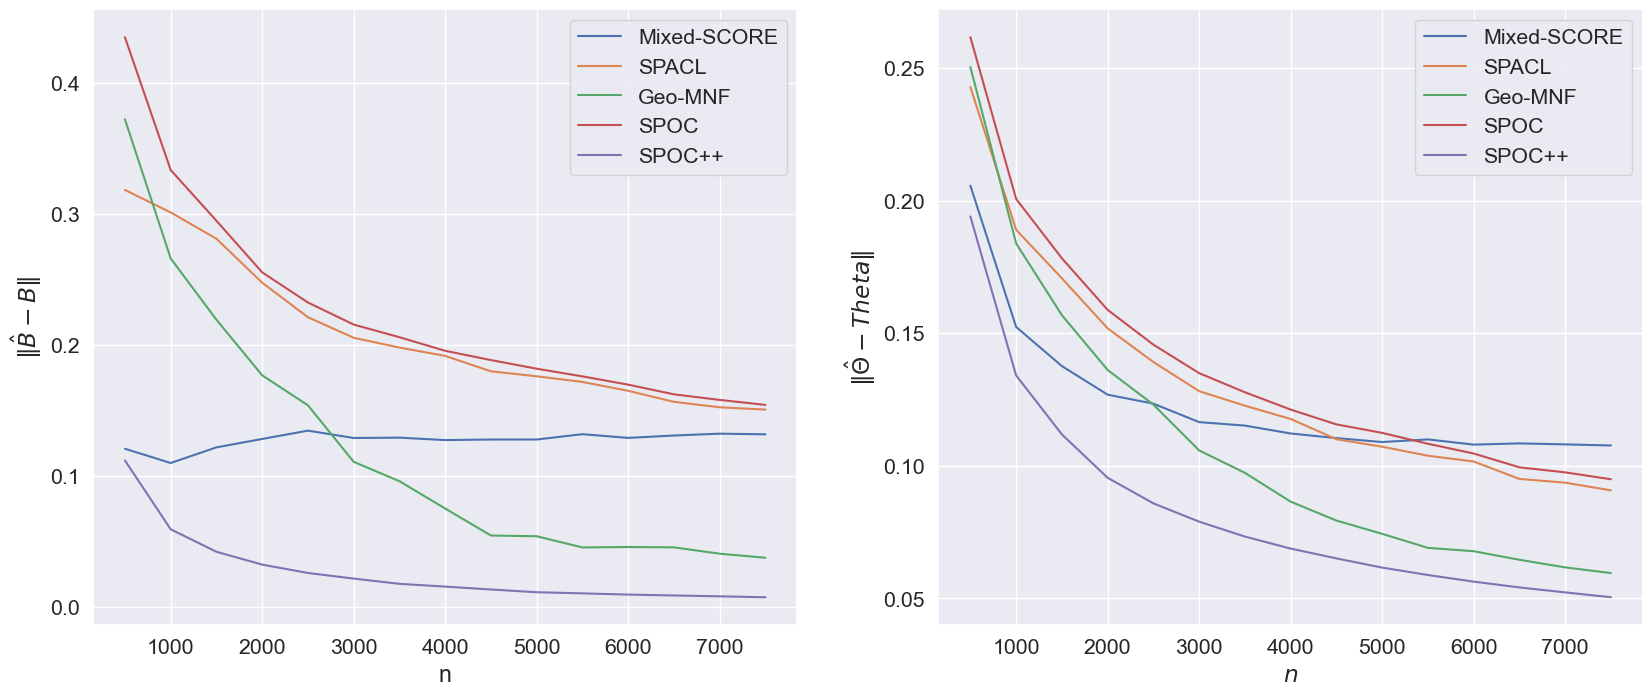

In [7]:
num_iters = 100
num_steps = 15
step = 500
n_clusters = 3

B = sps.uniform.rvs(size=(n_clusters, n_clusters))
B = 0.5 * (B + B.T)
B = 0.5 * B + 0.5 * np.eye(n_clusters)

generator = ModelGenerator(
    B.shape[0],
    B,
    0.73,
    model_type='MMSB'
)

experiments = []
error_mscore_B = np.zeros((num_steps, num_iters))
error_mscore_theta = np.zeros((num_steps, num_iters))
error_spacl_B = np.zeros((num_steps, num_iters))
error_spacl_theta = np.zeros((num_steps, num_iters))
error_geo_B = np.zeros((num_steps, num_iters))
error_geo_theta = np.zeros((num_steps, num_iters))
error_spocpp_theta = np.zeros((num_steps, num_iters))
error_spocpp_B = np.zeros((num_steps, num_iters))
error_spoc_theta = np.zeros((num_steps, num_iters))
error_spoc_B = np.zeros((num_steps, num_iters))
# error_aspoc_factor_2 = np.zeros((num_steps, num_iters))
# error_aspoc_log = np.zeros((num_steps, num_iters))
# error_aspoc_default = np.zeros((num_steps, num_iters))
# error_spoc_array = np.zeros((num_steps, num_iters))
# error_aspoc_factor_3 = np.zeros((num_steps, num_iters))

for n_nodes in range(step, step * (num_steps + 1), step):
    generator.generate_new_theta(step)
    rho = 1
    P = generator.calculate_P() * rho


    for iter in tqdm(range(num_iters)):
        A = gen_model.P_to_A(P)

        mixed_out = mixedSCORE(A, 3)
        
        Theta_est = mixed_out['memberships']
        # B_est = mixed_out['community_matrix']

        theta_inv_matrix = np.linalg.inv(Theta_est.T @ Theta_est)

        B_est = theta_inv_matrix @ Theta_est.T @ A @ Theta_est @ theta_inv_matrix

        error_mscore_B[
            n_nodes // step - 1, iter
        ] = gen_model.find_b_error(rho * B, B_est)

        error_mscore_theta[
            n_nodes // step - 1, iter
        ] = gen_model.find_theta_error(Theta_est, generator.current_theta)

        spacl_obj = SPACL()
        Theta_est, B_est = spacl_obj.fit(A, 3)

        error_spacl_B[
            n_nodes // step - 1, iter
        ] = gen_model.find_b_error(rho * B, B_est)

        error_spacl_theta[
            n_nodes // step - 1, iter
        ] = gen_model.find_theta_error(Theta_est, generator.current_theta)

        geoMNF_obj = GeoMNF()
        Theta_est, B_est = geoMNF_obj.fit(A, 3)

        error_geo_B[
            n_nodes // step - 1, iter
        ] = gen_model.find_b_error(rho * B, B_est)

        error_geo_theta[
            n_nodes // step - 1, iter
        ] = gen_model.find_theta_error(Theta_est, generator.current_theta)

        SPOCpp_object = SPOC(
            use_averaging=True,
            averaging_threshold=2 * np.log(n_nodes)
        )
        
        SPOC_object = SPOC(
            use_averaging=False
        )
        
        SPOCpp_theta, SPOCpp_B = SPOCpp_object.fit(A, n_clusters)
        SPOC_theta, SPOC_B = SPOC_object.fit(A, n_clusters)
        
        error_spocpp_theta[
            n_nodes // step - 1, iter
        ] = gen_model.find_theta_error(SPOCpp_theta, generator.current_theta)
        
        error_spocpp_B[
            n_nodes // step - 1, iter
        ] = gen_model.find_b_error(rho * B, SPOCpp_B)
        
        error_spoc_theta[
            n_nodes // step - 1, iter
        ] = gen_model.find_theta_error(SPOC_theta, generator.current_theta)
        
        error_spoc_B[
            n_nodes // step - 1, iter
        ] = gen_model.find_b_error(SPOC_B, B * rho)

    clear_output(wait=True)

    current_step = n_nodes // step

    mean_error_mscore_B = np.mean(error_mscore_B[:current_step], axis=1)
    mean_error_mscore_theta = np.mean(error_mscore_theta[:current_step], axis=1)

    mean_error_spacl_B = np.mean(error_spacl_B[:current_step], axis=1)
    mean_error_spacl_theta = np.mean(error_spacl_theta[:current_step], axis=1)

    mean_error_geo_B = np.mean(error_geo_B[:current_step], axis=1)
    mean_error_geo_theta = np.mean(error_geo_theta[:current_step], axis=1)


    mean_error_spoc_B = np.mean(error_spoc_B[:current_step], axis=1)
    mean_error_spoc_theta = np.mean(error_spoc_theta[:current_step], axis=1)

    mean_error_spocpp_B = np.mean(error_spocpp_B[:current_step], axis=1)
    mean_error_spocpp_theta = np.mean(error_spocpp_theta[:current_step], axis=1)

    

    # mean_error_aspoc_log = np.mean(error_aspoc_log[:current_step], axis=1)
    # mean_error_aspoc_default = np.mean(error_aspoc_default[:current_step], axis=1)
    # mean_error_spoc = np.mean(error_spoc_array[:current_step], axis=1)
    # mean_error_aspoc_reminder = np.mean(error_aspoc_reminder[:current_step], axis=1)

    plt.figure(figsize=(20, 8))

    plt.subplot(1, 2, 1)
    n_nodes_array = np.arange(step, step * (current_step + 1), step)


    plt.plot(
        n_nodes_array,
        mean_error_mscore_B,
        label='Mixed-SCORE'
    )

    plt.plot(
        n_nodes_array,
        mean_error_spacl_B,
        label='SPACL'
    )

    plt.plot(
        n_nodes_array,
        mean_error_geo_B,
        label='Geo-MNF'
    )

    plt.plot(
        n_nodes_array,
        mean_error_spoc_B,
        label='SPOC'
    )

    plt.plot(
        n_nodes_array,
        mean_error_spocpp_B,
        label='SPOC++'
    )

    plt.legend()
    plt.xlabel('n')
    plt.ylabel(r'$\Vert \hat B - B \Vert$')

    

    # plt.title('Large number of pure nodes')

    plt.subplot(1, 2, 2)


    plt.plot(
        n_nodes_array,
        mean_error_mscore_theta,
        label='Mixed-SCORE'
    )

    plt.plot(
        n_nodes_array,
        mean_error_spacl_theta,  
        label='SPACL'
    ) 
    plt.plot(
        n_nodes_array,
        mean_error_geo_theta,
        label='Geo-MNF'
    )

    plt.plot(
        n_nodes_array,
        mean_error_spoc_theta,
        label='SPOC'
    )

    plt.plot(
        n_nodes_array,
        mean_error_spocpp_theta,
        label='SPOC++'
    )




    plt.legend()
    plt.xlabel(r'$n$')
    plt.ylabel(r'$\Vert \hat \Theta - Theta \Vert$')

    # plt.title('Convergence rate')

    plt.show()

    experiment = {
        'B': B,
        'num_iters': num_iters,
        'n_nodes': np.arange(step, step * (num_steps + 1), step),
        'error_mscore_B': error_mscore_B[:current_step],
        'error_mscore_theta': error_mscore_theta[:current_step],
        'error_geo_B': error_geo_B[:current_step],
        'error_geo_theta': error_geo_theta[:current_step],
        'error_spacl_B': error_spacl_B[:current_step],
        'error_spacl_theta': error_spacl_theta[:current_step],
        'error_theta, SPOCpp': error_spocpp_theta[:current_step],
        'error_theta, SPOC': error_spoc_theta[:current_step],
        'error_B, SPOCpp': error_spocpp_B[:current_step],
        'error_B, SPOC': error_spoc_B[:current_step]
    }

    np.save(
        'n_dependence_net_experiment.npy',
        experiment,
        allow_pickle=True
    )

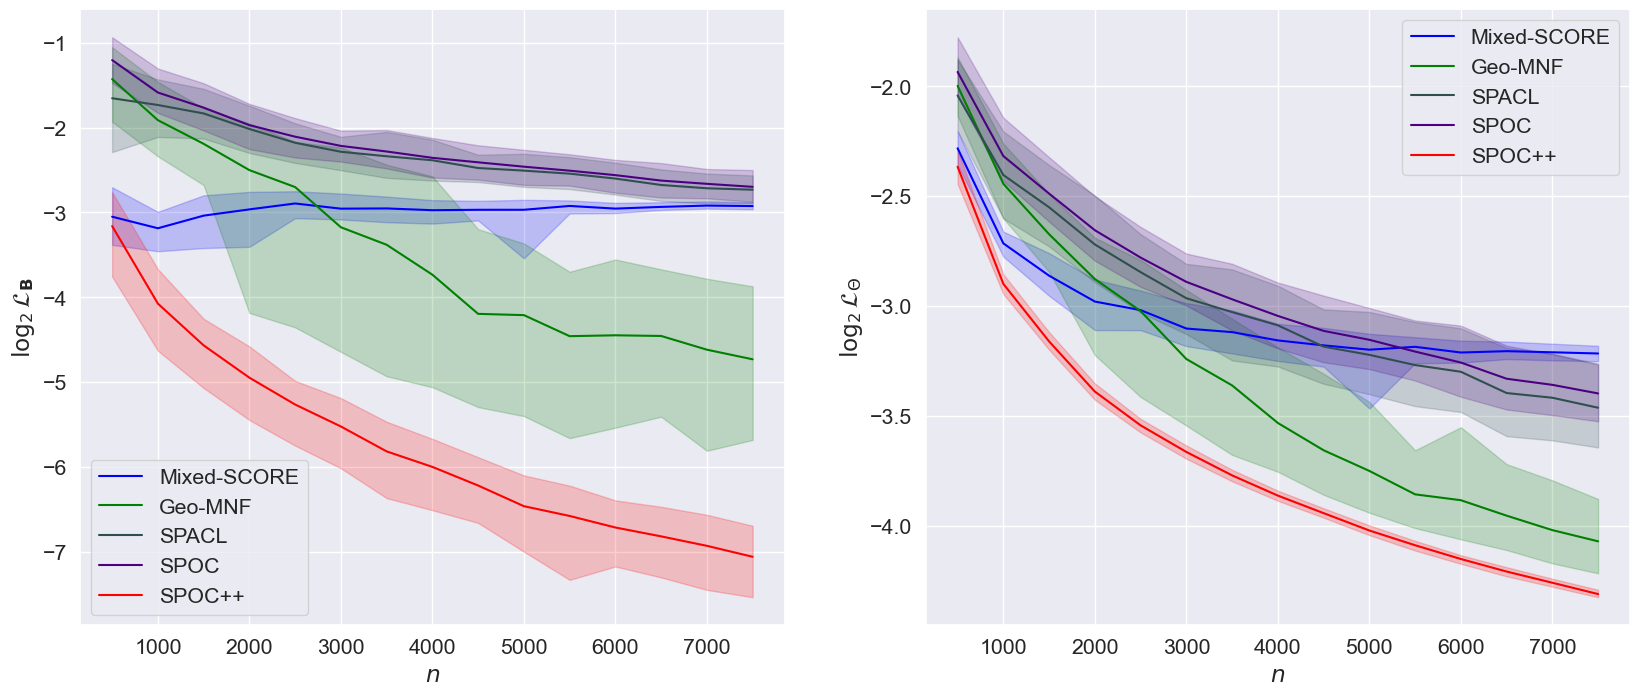

In [33]:
# from matplotlib.scale import LogScale

error_arrays_B = [error_mscore_B, error_geo_B, error_spacl_B, error_spoc_B, error_spocpp_B]
error_arrays_theta = [error_mscore_theta, error_geo_theta, error_spacl_theta, error_spoc_theta, error_spocpp_theta]
names = ['Mixed-SCORE', 'Geo-MNF', 'SPACL', 'SPOC', 'SPOC++']
colors = ['blue', 'green', 'darkslategray', 'indigo', 'red']

plt.figure(figsize=(20, 8))
# fig, ax = plt.subplots()
# ax.set_yscale('log', base=2)
plt.subplot(1, 2, 1)


for i in range(len(names)):
    plt.plot(n_nodes_array, np.log2(error_arrays_B[i].mean(axis=1)), label=names[i], color=colors[i])
    upper_quantile = np.quantile(error_arrays_B[i], 0.95, axis=1)
    lower_quantile = np.quantile(error_arrays_B[i], 0.05, axis=1)

    plt.fill_between(n_nodes_array, np.log2(lower_quantile), np.log2(upper_quantile), alpha=0.2, color=colors[i])

    # for iter in range(num_iters):
    #     plt.scatter(n_nodes_array, np.log2(error_arrays_B[i][:, iter]), alpha=0.3, color=colors[i])


plt.xlabel('$n$')
plt.ylabel(r'$\log_2 \mathcal{L}_{\mathbf{B}}$')
# ax.set_yscale('log', base=2)
plt.legend()
    

plt.subplot(1, 2, 2)

for i in range(len(names)):
    plt.plot(n_nodes_array, np.log2(error_arrays_theta[i].mean(axis=1)), label=names[i], color=colors[i])
    upper_quantile = np.quantile(error_arrays_theta[i], 0.95, axis=1)
    lower_quantile = np.quantile(error_arrays_theta[i], 0.05, axis=1)

    plt.fill_between(n_nodes_array, np.log2(lower_quantile), np.log2(upper_quantile), alpha=0.2, color=colors[i])

    # for iter in range(num_iters):
    #     plt.scatter(n_nodes_array, np.log2(error_arrays_theta[i][:, iter]), alpha=0.3, color=colors[i])

plt.xlabel('$n$')
plt.ylabel(r'$\log_2 \mathcal{L}_{\Theta}$')
plt.legend()

plt.savefig('full_comparison.pdf', bbox_inches='tight')

plt.show()